# 两地区 QSM：加入通勤

[在线章节](https://lianxhcn.github.io/qsm101/site/pages/commuting.html) · [网站首页](https://lianxhcn.github.io/qsm101/) · [课程主页](https://www.lianxh.cn/qsm.html) · [GitHub 仓库](https://github.com/lianxhcn/qsm101)

[下载本章 Notebook](../../articles/p05-commuting-qsm/downloads/commuting.ipynb) · [下载基准数据](../../articles/p05-commuting-qsm/data/teaching-baseline.csv) · [下载模拟选择数据](../../articles/p05-commuting-qsm/data/synthetic-joint-choice-tasks.csv) · [下载离线练习包](../../articles/p05-commuting-qsm/downloads/commuting-workbook.zip)

::: {.callout-note title="开始之前" icon=false}

适合读者：已经读过[无通勤两地区模型](laboratory.qmd)，希望理解住房政策如何分别改变居住地与工作地的研究生和研究者。先修要求是 Python 数组操作、对数与条件概率。

:::

本章结束后，你应能区分居民数、就业数和通勤流量；用四选项样本演示参数估计；反演对称教学基准并求住房政策均衡；用共同冲击、极端通勤成本和市场出清检查结果。全文只使用教学构造，不对应真实城市。

::: {.callout-tip title="离线运行" icon=false}

Notebook 包含全部模型函数，可独立运行，不调用仓库中的参考脚本。解压离线练习包后，Notebook 与 data/ 位于同一目录；在已有 Python 环境安装 numpy、scipy、pandas、matplotlib、jupyterlab 后打开并从头执行。网页保留已执行输出，方便先阅读再下载练习。

:::

## 1. 住房与就业的联系 {#住房建在-b就业一定增加在-b-吗}

住房建在 B 地区，就业一定增加在 B 吗？允许通勤后，需要分别追踪居住人口与就业人数。

前一章无通勤模型 中，工人住在哪里，就在哪里工作。因此，B 地区多建住房以后，B 的居民数和就业数总是同增同减。真实城市并不如此。有人住在郊区，到中心城区工作；也有人因房租下降搬到一个地区，却没有改变工作地点。

这一区别会改变我们对住房政策的理解。B 地区增加住房以后，迁入 B 的居民可以在 B 工作，也可以每天前往 A。住房政策的直接作用是改变居住地选择；就业、工资和通勤流量还要通过新的均衡共同决定。

本文在 前一章无通勤模型 的两地区框架中加入通勤。我们仍考察 B 地区有效住房服务存量增加 20% 的政策，但把每个工人的选择改为「住在何处、在哪里工作」的四种组合。新模型会分别计算居民数、就业数和双向通勤人数。文中的教学数据及参数均由本项目构造，不对应任何实际城市；下文政策数值由本地程序实际求解，并通过基准复原、市场出清与共同冲击等核验。

设城市只有 A、B 两个地区。前一章无通勤模型 中，B 的劳动人口从 4 万增加到 4.2 万，可以同时理解为 B 的居民增加和 B 的就业增加。引入通勤后，这种写法不再成立。

令 $M_{ij}$ 表示住在地区 $i$、工作在地区 $j$ 的工人数。四个单元构成一个居住地—工作地通勤表：

| 居住地 \ 工作地 | A | B | 居住地合计 |
|---|---:|---:|---:|
| A | $M_{AA}$ | $M_{AB}$ | $R_{A}$ |
| B | $M_{BA}$ | $M_{BB}$ | $R_{B}$ |
| 就业地合计 | $E_{A}$ | $E_{B}$ | $N$ |

本文的居民数指按居住地统计的模型工人数，不包含儿童、退休人员等全部常住人口。其中，$R_{i}$ 是地区 $i$ 的居民数，$E_{j}$ 是地区 $j$ 的就业数，满足：

$$
R_{i}=\sum_{j}M_{ij},\qquad E_{j}=\sum_{i}M_{ij},\qquad \sum_{i,j}M_{ij}=N.
$$

例如，$M_{BA}$ 是住在 B、工作在 A 的人数。它增加时，B 的住房需求增加，A 的劳动投入增加。两种调整发生在不同地区，因此房租和工资也由不同的总量决定。

这一写法是后文所有机制的基础：**工资由就业地的就业数决定，房租由居住地居民的住房需求决定。**


## 2. 联合选择与市场出清 {#把四种选择与两个市场连接起来}

四种居住地与工作地组合连接到劳动力市场和住房市场，联合决定人口分布、工资与房租。

### 2.1 居住与就业选择 {#居住地与工作地的联合选择}

每个工人选择一个居住地 $i$ 和工作地 $j$。仍设普通商品价格为 1，住房支出份额为 $\alpha$，居住地 $i$ 的单位房租为 $r_{i}$，工作地 $j$ 的工资为 $w_{j}$。工人的效用与预算约束为：

$$
U_{nij}=\ln B_{i}+(1-\alpha)\ln c+\alpha\ln h-\tau_{ij}+\varepsilon_{nij},
\qquad c+r_{i}h=w_{j}.
$$

$B_{i}$ 是居住地便利度，$\tau_{ij}$ 是从 $i$ 到 $j$ 的广义通勤成本，$\varepsilon_{nij}$ 是工人 $n$ 对这一居住地—工作地组合的个体偏好。本文将 $\tau_{ij}$ 解释为以效用单位表示的通勤时间、拥挤和不便损失，而不把它从工资收入中扣除。因此，通勤成本影响选择和工人福利，但本教学特例不单列交通部门收入、燃油支出或道路建设成本。

令 $\tau_{AA}=\tau_{BB}=0$，并在两地区教学基准中设 $\tau_{AB}=\tau_{BA}=\tau>0$。在实际研究中，通勤时间、距离和票价可能具有方向差异，应据数据设置 $\tau_{ij}$。

给定居住地和工作地后，最优住房需求仍为 $h=\alpha w_{j}/r_{i}$。代回效用，得到组合 $(i,j)$ 的系统部分：

$$
V_{ij}=\ln B_{i}+\ln w_{j}-\alpha\ln r_{i}-\tau_{ij}+C_{\alpha},
$$

$$
C_{\alpha}=(1-\alpha)\ln(1-\alpha)+\alpha\ln\alpha.
$$

若 $\varepsilon_{nij}$ 独立同分布并服从尺度为 $1/\theta$ 的 I 型极值分布，则四种组合的预期份额为：

$$
p_{ij}=\frac{\exp\{\theta(\ln B_{i}+\ln w_{j}-\alpha\ln r_{i}-\tau_{ij})\}}
{\sum_{k\in\{A,B\}}\sum_{\ell\in\{A,B\}}\exp\{\theta(\ln B_{k}+\ln w_{\ell}-\alpha\ln r_{k}-\tau_{k\ell})\}},
\qquad M_{ij}=Np_{ij}.
$$

这里的 $\theta>0$ 衡量工人对系统效用差异的敏感程度。$\theta$ 越大，相同的工资、房租或通勤成本变化带来更大的空间重新配置。

固定居住地 $i$ 后，选择工作地的条件概率为：

$$
\Pr(j\mid i)=\frac{M_{ij}}{R_{i}}
=\frac{\exp\{\theta(\ln w_{j}-\tau_{ij})\}}
{\sum_{\ell\in\{A,B\}}\exp\{\theta(\ln w_{\ell}-\tau_{i\ell})\}}.
$$

这就是本篇的通勤引力关系：目的地工资较高会吸引工人，通勤成本较高会减少通勤流量。更完整的城市模型还会引入多个街区、不同类型工人和工作岗位；Ahlfeldt 等 ([2015](https://doi.org/10.3982/ECTA10876)) 利用通勤决策中的随机冲击得到可估计的通勤引力方程。本文只保留两地区和同质工人，以便看清均衡反馈。

### 2.2 工资和住房市场

企业在工作地 $j$ 使用劳动和固定的非劳动要素生产普通商品。将固定要素吸收进 $Z_{j}$，生产函数与竞争性工资为：

$$
Y_{j}=Z_{j}E_{j}^{\beta},\qquad
w_{j}=\beta Z_{j}E_{j}^{\beta-1},\qquad 0<\beta<1.
$$

这里的劳动投入是就业人数 $E_{j}$。在生产率与固定要素不变时，A 地区就业总量增加会降低其劳动边际产出和工资。仅改变居住地、保持工作地不变，不会直接改变工作地的劳动投入。例如，一个原本住 A、在 A 工作的工人搬到 B 后仍在 A 工作，A 的就业数并未因此增加。

住房服务固定在居住地。由于住在 $i$、工作在 $j$ 的工人将工资中的 $\alpha$ 比例用于住房，地区 $i$ 的住房市场出清条件为：

$$
r_{i}H_{i}=\alpha\sum_{j\in\{A,B\}}w_{j}M_{ij}.
$$

$H_{i}$ 是地区 $i$ 的有效住房服务存量。B 地区住房扩建会直接提高 $H_{B}$；它通过降低 B 的房租吸引居民，但迁入者的工资取决于他们在哪里工作。

该设定沿用 前一章无通勤模型 的收入归属：工人只取得工资收入，住房和固定生产要素由区外所有者持有。因为通勤成本在本篇中是时间和便利度损失，工人消费、房租收入与生产收入的核算仍可闭合。若研究问题涉及地铁票价、拥堵收费或建设成本，需要显式加入交通服务供给和政府预算，不能将本篇的福利变化直接解释为交通项目的净社会收益。


## 3. 数据、估计与校准 {#读取固定数据估计参数并校准基准}

为了比较允许通勤与仅本地工作两个模型，本章使用对称的教学基准。前一章无通勤模型采用另一组不对称数据，其结果不能直接作为本篇的对照组。设总工人数为 12 万，两地各有 6 万居民和 6 万就业岗位；每个地区的月工资为 9,600 元、单位住房月租金为 120 元/平方米。住房支出份额设为 $\alpha=0.25$，劳动产出弹性设为 $\beta=0.90$。

基准通勤表设为：

| 居住地 \ 工作地 | A | B | 居住地合计 |
|---|---:|---:|---:|
| A | 54,000 | 6,000 | 60,000 |
| B | 6,000 | 54,000 | 60,000 |
| 就业地合计 | 60,000 | 60,000 | 120,000 |

因此，两地各有 10% 的居民跨区通勤，净通勤流量为零。这个对称设计并非现实城市事实，而是为了让「允许通勤」和「居住地必须等于工作地」两个模型拥有相同的居民数、就业数、工资和房租基准，从而清楚比较住房冲击的传导差异。



### 3.1 数据检查 {#先检查数据口径与完整性}

下面先读取两份固定 CSV。程序优先查找本地 data/ 和仓库数据目录；本地缺失才尝试公开仓库，并核对 SHA256。离线使用时应解压完整练习包。加载失败时保留错误说明，不用临时随机样本替代固定输入。


In [1]:
from pathlib import Path
from io import BytesIO
from urllib.request import urlopen
import hashlib, json, sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy.optimize import root, minimize
from scipy.special import softmax, logsumexp
from IPython.display import display

RAW_BASE = "https://raw.githubusercontent.com/lianxhcn/qsm101/main/articles/p05-commuting-qsm/data"
EXPECTED_HASHES = {'synthetic-joint-choice-tasks.csv': '4b205213dc543a8277cd942f865539d4053d0c828aeecc5fbc740fdd4b63ceb4', 'teaching-baseline.csv': '9a074cbb924e0864a36a8daddfd3eb7a4996e45586af3e29a9ed2bde26012d15'}

def load_csv(name):
    """优先读取固定本地样本；没有文件时才尝试同版本公开输入。"""
    candidates = [Path('data')/name, Path(name),
        Path('articles/p05-commuting-qsm/data')/name,
        Path('../../articles/p05-commuting-qsm/data')/name]
    found = next((p for p in candidates if p.is_file()), None)
    if found is not None:
        payload = found.read_bytes()
        origin = '本地固定数据'
    else:
        try:
            with urlopen(f'{RAW_BASE}/{name}', timeout=20) as response:
                payload = response.read()
            origin = '公开仓库固定数据'
        except Exception as exc:
            raise RuntimeError('无法取得固定数据。请下载离线练习包，解压后保留 data/ 目录。') from exc
    digest = hashlib.sha256(payload).hexdigest()
    if digest != EXPECTED_HASHES[name]:
        raise ValueError(f'{name} 哈希不匹配，请核对 Notebook 与数据版本。')
    return pd.read_csv(BytesIO(payload)), origin

baseline_data, baseline_origin = load_csv('teaching-baseline.csv')
data, data_origin = load_csv('synthetic-joint-choice-tasks.csv')
M0 = baseline_data.pivot(index='home_region', columns='work_region', values='commuters').loc[['A','B'],['A','B']].to_numpy()
W0 = baseline_data.groupby('work_region').monthly_wage.first().loc[['A','B']].to_numpy()
RENT0 = baseline_data.groupby('home_region').monthly_rent_per_m2.first().loc[['A','B']].to_numpy()
N = float(M0.sum())
ALPHA, BETA, THETA = [float(baseline_data[k].iloc[0]) for k in ['alpha','beta','theta']]
TAU = float(baseline_data.query("home_region == 'A' and work_region == 'B'").tau.iloc[0])
SEED, SAMPLE_SIZE = 20261005, 20000
REGIONS = np.array(['A','B'])
STARTS = [(0.,0.),(-2.,-2.),(2.,2.),(-2.,2.),(2.,-2.)]
assert N == 120000 and data.choice_set_id.nunique() == SAMPLE_SIZE
assert (data.groupby('choice_set_id').size() == 4).all()
assert (data.groupby('choice_set_id').chosen.sum() == 1).all()
print(f'基准：{baseline_origin}；模拟任务：{data_origin}；哈希均匹配。')
print(f'总工人数 {N:,.0f}；选择集 {SAMPLE_SIZE:,}；样本行数 {len(data):,}。')
display(data[['choice_set_id','home_region','work_region','commute_indicator','commute_multiplier','chosen']].head(4))


基准：本地固定数据；模拟任务：本地固定数据；哈希均匹配。
总工人数 120,000；选择集 20,000；样本行数 80,000。


,choice_set_id,home_region,work_region,commute_indicator,commute_multiplier,chosen
0,0,A,A,0,0.000000,1
1,0,A,B,1,0.848916,0
2,0,B,A,1,0.857847,0
3,0,B,B,0,0.000000,0


一个 choice_set_id 对应一个工人的四选项任务，只有一个 chosen=1。基准表中的居民数和就业数会在四行中重复出现，不能直接将重复边际字段相加。

### 3.2 模拟参数估计 {#模拟估计回答什么问题}

程序按 [model.md](../../articles/p05-commuting-qsm/model.md) 的完整规则生成 20,000 个独立的四选项任务 (共 80,000 行)，种子为 20261005。工资、租金和跨区通勤强度独立变化；固定住房份额后估计 $\theta$ 和 $\theta\tau$，再恢复 $\tau$。

| 参数 | 模拟真值 | 估计值 | IID 标准误 |
|---|---:|---:|---:|
| $\theta$ | 4.000000 | 3.907169 | 0.064449 |
| $\kappa=\theta\tau$ | 2.197225 | 2.178161 | 0.024721 |
| $\tau$ | 0.549306 | 0.557478 | 0.011073 |

这些标准误仅针对独立模拟任务，不能解释为真实政策预测的不确定性。通勤成本标准误用 Delta 法并保留两个估计系数的协方差。主均衡仍使用教学真值，模拟估计结果只用于检验估计程序及附加敏感性演示。真实应用需要处理工资、租金的内生性及遗漏区位特征，AI 编写代码不能代替这些判断。

估计时使用 $V_{nij}=\theta(\ln w_{nj}-\alpha\ln r_{ni})-\kappa d_{nij}$，其中 $d_{nij}$ 为连续通勤强度 `commute_multiplier`，本地取 0，跨区在不同任务中变化。二元变量 `commute_indicator` 只用于标记是否跨区，不能替代这个连续变量。通勤参数以效用单位度量，不能直接读成分钟或元。



下列函数最小化平均负对数似然。信息矩阵按独立任务累加，四个备选项不是四个独立工人。代码中的 X 对同一任务的属性中心化，不改变选择概率。


In [2]:
#| code-fold: true
def estimate(df):
    """解析梯度与观测信息矩阵；tau 的标准误使用含协方差的 Delta 法。"""
    n = len(df)//4
    x = (df.log_wage-ALPHA*df.log_rent).to_numpy().reshape(n,4)
    d = df.commute_multiplier.to_numpy().reshape(n,4)
    X = np.stack([x, -d], axis=2)
    # 每个选择集中心化，不影响概率；有助于数值条件。
    X -= X.mean(1, keepdims=True)
    chosen = df.chosen.to_numpy().reshape(n,4)
    def fg(b):
        v = X@b
        prob = softmax(v, axis=1)
        loss = np.mean(logsumexp(v, axis=1)-(chosen*v).sum(1))
        grad = np.einsum('na,nak->k', prob-chosen, X)/n
        return loss, grad
    fit = minimize(fg, [3., 2.], jac=True, method='BFGS',
                   options={'gtol': 1e-10, 'maxiter': 1000})
    prob = softmax(X@fit.x, axis=1)
    mu = np.einsum('na,nak->nk', prob, X)
    info = (np.einsum('na,nak,nal->kl', prob, X, X)-mu.T@mu)
    cov = np.linalg.inv(info)
    theta, penalty = fit.x
    delta = np.array([-penalty/theta**2, 1/theta])
    values = np.array([theta, penalty, penalty/theta])
    se = np.r_[np.sqrt(np.diag(cov)), np.sqrt(delta@cov@delta)]
    true = np.array([THETA, THETA*TAU, TAU])
    rank = np.linalg.matrix_rank(X.reshape(-1,2))
    score = np.max(np.abs(fg(fit.x)[1]))
    if not fit.success or score > 1e-7 or theta <= 0 or penalty <= 0:
        raise RuntimeError(f'MLE 失败: {fit.message}, score={score}')
    out = pd.DataFrame(dict(parameter=['theta','theta_tau','tau'],
        true_value=true, estimate=values, iid_standard_error=se,
        ci95_low=values-1.96*se, ci95_high=values+1.96*se,
        z_from_truth=(values-true)/se, seed=SEED, choice_sets=n,
        data_origin='synthetic_choice_experiment'))
    meta = dict(success=bool(fit.success), status=int(fit.status),
                message=str(fit.message), mean_score_max=score,
                design_rank=int(rank), information_eigenvalues=np.linalg.eigvalsh(info),
                covariance=cov, seed=SEED, choice_sets=n, rows=len(df))
    return out, meta


In [3]:
estimates, mle = estimate(data)
display(estimates[['parameter','true_value','estimate','iid_standard_error']].round(6))
print('优化器收敛：', mle['success'], '；设计矩阵秩：', mle['design_rank'])


,parameter,true_value,estimate,iid_standard_error
0,theta,4.000000,3.907169,0.064449
1,theta_tau,2.197225,2.178161,0.024721
2,tau,0.549306,0.557478,0.011073


优化器收敛： True ；设计矩阵秩： 2


看 estimate 与 true_value 的差异，再看标准误。模拟只验证估计程序是否能恢复已知参数；固定样本上的一次恢复不是覆盖率实验。主政策继续采用教学真值，估计值将在敏感性情景中单独使用。

### 3.3 基准反演 {#给定行为参数后反演基本面}



教学程序设 $\theta=4$。由 $M_{AB}/M_{AA}=1/9$ 可反演对称通勤成本：

$$
\tau=-\frac{1}{\theta}\ln\left(\frac{M_{AB}}{M_{AA}}\right)=\frac{\ln 9}{4}.
$$

取 $B_{A}=B_{B}=1$。给定基准通勤表、工资和房租，住房存量与生产率可由：

$$
H_{i}=\frac{\alpha\sum_{j}w_{j}^{0}M_{ij}^{0}}{r_{i}^{0}},
\qquad
Z_{j}=\frac{w_{j}^{0}(E_{j}^{0})^{1-\beta}}{\beta}
$$

反演。两地在此教学基准下均有 $H_{i}=120$ 万平方米。$H_{i}$ 和 $Z_{j}$ 是与模型条件相对应的有效量；基准拟合不构成对模型的外部验证。

真实研究至少需要四类数据：

| 对象 | 需要的口径 | 典型来源或处理 |
|---|---|---|
| 通勤流量 $M_{ij}$ | 同一时点、同一就业人群的居住地—工作地交叉表 | 人口普查通勤表、交通调查、带住址和工作地的调查或行政数据 |
| 居民数 $R_{i}$ 与就业数 $E_{j}$ | 分别按居住地和工作地统计 | 行合计与列合计须能与通勤表核对 |
| 工资 $w_{j}$ 与房租 $r_{i}$ | 工资按工作地，房租按居住地；统一人群、时间单位和住房质量 | 劳动调查、工资统计、租赁合同或住房调查 |
| 通勤成本 $\tau_{ij}$ | 距离、时间、票价、换乘或拥挤等信息 | 路网、手机轨迹、地图 API、交通调查；需说明如何映射到效用单位 |

两行人口与工资数据不足以识别通勤成本。若使用多项选择模型估计 $\theta$ 和 $\tau$，需要观察工人的备选居住地—工作地组合，或者采用具有明确属性变化的选择实验。仅将基准通勤表拟合得很好，不能替代这一识别工作。


In [4]:
#| code-fold: true
def rel(a, b):
    return float(np.max(np.abs(np.asarray(a)-np.asarray(b))/
                        np.maximum(np.abs(b), 1e-12)))

def calibrate(theta=THETA, beta=BETA, tau=None, restricted=False):
    """theta 网格保持 OD 基准，tau 网格仅保持总量基准，不能同时强配 OD。"""
    if not (theta > 0 and 0 < beta <= 1):
        raise ValueError('参数越界')
    tau = np.log(9.) / theta if tau is None else float(tau)
    if tau < 0:
        raise ValueError('通勤成本必须非负')
    target = np.diag(M0.sum(1)) if restricted else M0.copy()
    R, E = target.sum(1), target.sum(0)
    H = ALPHA * (target @ W0) / RENT0
    Z = W0 * E ** (1-beta) / beta
    # 对称工资、租金、行和以及对称通勤成本意味着相对便利度为 1。
    return dict(N=N, alpha=ALPHA, beta=beta, theta=theta,
                tau=np.array([[0., tau], [tau, 0.]]), H=H, Z=Z,
                B=np.ones(2), mask=np.eye(2, dtype=bool) if restricted
                else np.ones((2, 2), dtype=bool), restricted=restricted)


In [5]:
p = calibrate()
restricted = calibrate(restricted=True)
display(pd.DataFrame({'地区':REGIONS, '有效住房平方米':p['H'],
                      '生产率复合项':p['Z'], '相对便利度':p['B']}))


,地区,有效住房平方米,生产率复合项,相对便利度
0,A,1200000.0,32051.167118,1.0
1,B,1200000.0,32051.167118,1.0


两地住房存量均反演为 120 万平方米。Z 是在给定生产函数下匹配工资与就业的复合项，其数值取决于单位。受限模型从对角流量重新校准总量基准；对称条件使两套模型的 H、Z 数值相同，不代表可以在一般数据下直接复用。


## 4. 两维均衡求解 {#两维均衡求解在做什么}

前一章无通勤模型只有一个独立的人口份额。本章通勤模型至少有两个独立总量：B 的居民份额与 B 的就业份额。可以令：

$$
x=\ln\left(\frac{R_{B}}{R_{A}}\right),\qquad
y=\ln\left(\frac{E_{B}}{E_{A}}\right).
$$

给定 $(x,y)$，程序先恢复 $R_{i}$、$E_{j}$，再按生产函数计算工资、按住房市场计算房租、由四种选择概率计算 $M_{ij}$。求解器调整 $(x,y)$，直至模型计算出的居民和就业边际份额同时等于候选份额。本章通勤模型 不声称这个两变量特例具有一般的解析解或普遍唯一性，应报告数值收敛情况，并用经济条件检查结果。



给定候选 R、E，先计算工作地工资，再由条件概率得到各居住地的平均工资。候选租金是住房支出除以住房存量。随后计算四格联合概率，要求其 B 居民份额和 B 就业份额分别等于候选值。最终验收仍用联合通勤流量重新计算住房需求。

每个情景尝试五组初值。hybr 在机器精度附近报告无进展时，保留原始状态，改用 lm 求解同样的方程；只有数值残差和经济条件同时达标才接受。多个初值一致也不构成一般模型唯一性的证明。


In [6]:
#| code-fold: true
def state(xy, p, H_hat=(1., 1.), Z_hat=(1., 1.)):
    """候选 R/E 下住房条件的代入，不把候选通勤矩阵当成最终均衡。"""
    R = p['N'] * softmax([0., xy[0]])
    E = p['N'] * softmax([0., xy[1]])
    H, Z = p['H'] * np.asarray(H_hat), p['Z'] * np.asarray(Z_hat)
    Y = Z * E ** p['beta']
    w = p['beta'] * Z * E ** (p['beta']-1)
    conditional_score = np.where(p['mask'], p['theta'] *
                                (np.log(w)[None, :] - p['tau']), -np.inf)
    q = softmax(conditional_score, axis=1)
    r = p['alpha'] * R * (q @ w) / H
    v = (np.log(p['B'])[:, None] + np.log(w)[None, :]
         - p['alpha'] * np.log(r)[:, None] - p['tau'])
    score = np.where(p['mask'], p['theta'] * v, -np.inf)
    prob = np.exp(score-logsumexp(score))
    M = p['N'] * prob
    residual = np.array([(M.sum(1)[1]-R[1])/p['N'],
                         (M.sum(0)[1]-E[1])/p['N']])
    return dict(R=R, E=E, w=w, r=r, M=M, p=prob, H=H, Z=Z, Y=Y,
                logW=logsumexp(score)/p['theta'], residual=residual,
                xy=np.asarray(xy))


In [7]:
#| code-fold: true
def solve(p, H_hat=(1., 1.), Z_hat=(1., 1.)):
    """多初值二维求根；失败或残差超标就报错，禁止按预期结果调参。"""
    if np.any(np.asarray(H_hat) <= 0) or np.any(np.asarray(Z_hat) <= 0):
        raise ValueError('冲击倍率必须为正')
    solutions, attempts = [], []
    for initial in STARTS:
        fun = lambda xy: state(xy, p, H_hat, Z_hat)['residual']
        fit = root(fun, initial, method='hybr', options={'xtol': 1e-10})
        primary = dict(success=bool(fit.success), status=int(fit.status),
                       message=str(fit.message), residual=float(np.max(np.abs(fun(fit.x)))))
        if not fit.success:
            # 对称解附近 hybr 可能因舍入误差停止；备用算法仍求相同方程。
            fit = root(fun, fit.x, method='lm',
                       options={'ftol':1e-12,'xtol':1e-12,'gtol':1e-12})
        s = state(fit.x, p, H_hat, Z_hat)
        err = float(np.max(np.abs(s['residual'])))
        attempts.append(dict(initial=initial, success=bool(fit.success),
                             status=int(fit.status), message=str(fit.message),
                             nfev=int(fit.nfev), residual=err, xy=fit.x, primary_hybr=primary))
        if err > 1e-10 or not fit.success:
            raise RuntimeError(f'求根失败: {attempts[-1]}')
        solutions.append(s)
    s = solutions[0]
    s['initial_spread'] = max(float(np.max(np.abs(v['xy']-s['xy'])))
                              for v in solutions)
    if s['initial_spread'] > 1e-8:
        raise RuntimeError('初值对应不同解，需要检查')
    s['attempts'] = attempts
    return s


In [8]:
states, params, baselines = {}, {}, {}
def add(name, pa, h=(1.,1.), z=(1.,1.), base='baseline'):
    states[name] = solve(pa, h, z)
    params[name], baselines[name] = pa, base
    return states[name]
base = add('baseline', p)
policy = add('B_housing_plus20', p, h=(1.,1.2))
add('zero_shock',p)
add('common_housing_plus20',p,h=(1.2,1.2))
add('common_productivity_plus10',p,z=(1.1,1.1))
rb = add('restricted_baseline',restricted,base='restricted_baseline')
rp = add('restricted_B_housing_plus20',restricted,h=(1.,1.2),base='restricted_baseline')
high = calibrate(tau=20.)
hb = add('high_tau_baseline',high,base='high_tau_baseline')
hp = add('high_tau_B_housing_plus20',high,h=(1.,1.2),base='high_tau_baseline')
print('基准及主政策求解完成。基准四格通勤矩阵：')
display(pd.DataFrame(base['M'],index=['住 A','住 B'],columns=['工作 A','工作 B']).round(2))


基准及主政策求解完成。基准四格通勤矩阵：


,工作 A,工作 B
住 A,54000.0,6000.0
住 B,6000.0,54000.0


## 5. 住房扩建的均衡结果 {#住房扩建后居民与就业如何分别调整}

政策设为：

$$
\widehat H_{A}=1,\qquad \widehat H_{B}=1.20.
$$

便利度 $B_{i}$、生产率 $Z_{j}$、通勤成本 $\tau_{ij}$、总工人数及行为参数在反事实中保持不变。程序同时求出居民数和就业数，使四种组合的选择概率、工资条件和两个住房市场条件全部成立。



下面同时报告居民数与就业数。人口在正文中取整数便于阅读；计算与核验保留完整精度。


In [9]:
def policy_table(new, old):
    names={'R':'居民数 (人)','E':'就业数 (人)','w':'工资 (元/月)','r':'租金 (元/平方米/月)'}
    rows=[]
    for key,label in names.items():
        for i,region in enumerate(REGIONS):
            rows.append({'指标':label,'地区':region,'基准':old[key][i],
                         '政策后':new[key][i],'变化 (%)':100*(new[key][i]/old[key][i]-1)})
    return pd.DataFrame(rows)
display(policy_table(policy,base).round(2))


,指标,地区,基准,政策后,变化 (%)
0,居民数 (人),A,60000.0,57478.31,-4.20
1,居民数 (人),B,60000.0,62521.69,4.20
2,就业数 (人),A,60000.0,58236.74,-2.94
3,就业数 (人),B,60000.0,61763.26,2.94
4,工资 (元/月),A,9600.0,9628.68,0.30
5,工资 (元/月),B,9600.0,9572.23,-0.29
6,租金 (元/平方米/月),A,120.0,115.23,-3.97
7,租金 (元/平方米/月),B,120.0,103.96,-13.36


B 地区居民增加约 2,522 人，就业增加约 1,763 人。政策后的居民数约为 62,522，就业数约为 61,763，二者相差约 758 人。住房需求随居住地居民收入变化；工资则随工作地就业量调整。

先看各变量相对基准的变化，比较允许通勤与只允许本地工作两个模型。


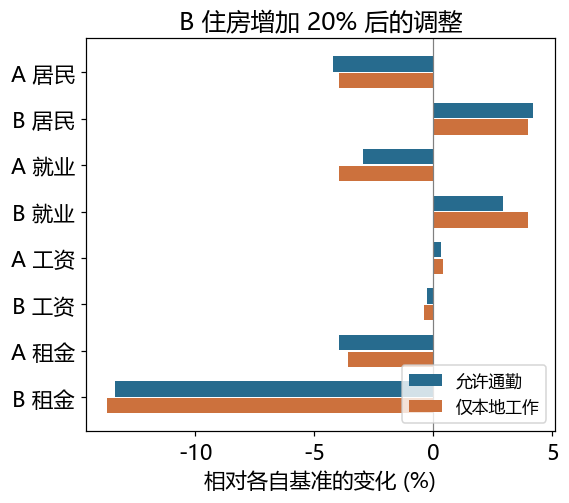

In [10]:
available={f.name for f in font_manager.fontManager.ttflist}
font=next((f for f in ['Microsoft YaHei','Noto Sans CJK SC','SimHei'] if f in available),None)
if font is None:
    raise RuntimeError('绘图需要中文字体，请安装可用中文字体后重新执行本格。表格数值不受影响。')
plt.rcParams.update({'font.family':font,'font.size':14,'axes.unicode_minus':False,
                     'figure.dpi':110,'svg.fonttype':'path'})
fig,ax=plt.subplots(figsize=(5.4,4.8))
y=np.arange(8)
for offset,s,s0,label,color in [(-.18,policy,base,'允许通勤','#276b8e'),(.18,rp,rb,'仅本地工作','#cc713d')]:
    values=np.concatenate([100*(s[k]/s0[k]-1) for k in ['R','E','w','r']])
    ax.barh(y+offset,values,height=.33,label=label,color=color)
ax.set_yticks(y,['A 居民','B 居民','A 就业','B 就业','A 工资','B 工资','A 租金','B 租金'])
ax.invert_yaxis();ax.axvline(0,color='gray',lw=.8)
ax.set_xlabel('相对各自基准的变化 (%)')
ax.legend(loc='lower right',fontsize=11)
ax.set_title('B 住房增加 20% 后的调整',fontsize=16)
fig.tight_layout();plt.show()


允许通勤时，B 居民增长约 4.20%，就业增长约 2.94%。受限模型中居民与就业增长相同，约为 3.96%。通勤允许一部分居住调整与工作地调整分开，B 的新增居民不必全部在 B 就业。下表进一步检查四格流量。


,工作 A,工作 B
住 A,51851.00,5627.32
住 B,6385.75,56135.94


B 净向 A 通勤 758.43 人；B 居民减就业 758.43 人。


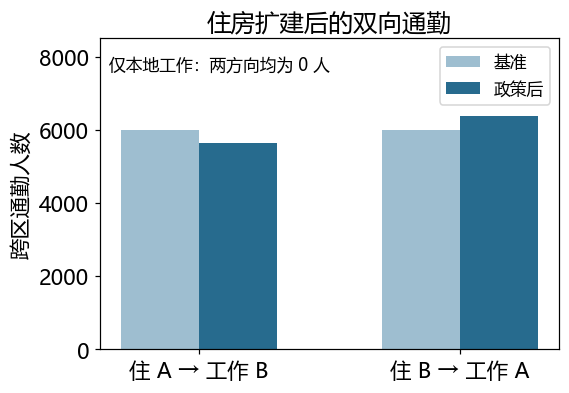

In [11]:
display(pd.DataFrame(policy['M'],index=['住 A','住 B'],columns=['工作 A','工作 B']).round(2))
net_to_A = policy['M'][1,0]-policy['M'][0,1]
print(f'B 净向 A 通勤 {net_to_A:,.2f} 人；B 居民减就业 {policy["R"][1]-policy["E"][1]:,.2f} 人。')
fig,ax=plt.subplots(figsize=(5.4,3.8))
for off,s,label,color in [(-.15,base,'基准','#9ebed0'),(.15,policy,'政策后','#276b8e')]:
    ax.bar(np.arange(2)+off,[s['M'][0,1],s['M'][1,0]],width=.3,label=label,color=color)
ax.set_xticks([0,1],['住 A → 工作 B','住 B → 工作 A'])
ax.set_ylabel('跨区通勤人数');ax.set_ylim(0,8500)
ax.legend(loc='upper right',fontsize=11)
ax.text(.02,.94,'仅本地工作：两方向均为 0 人',transform=ax.transAxes,fontsize=11,va='top')
ax.set_title('住房扩建后的双向通勤',fontsize=16)
fig.tight_layout();plt.show()


住 B 且在 B 工作的人数增加约 2,136，住 B 到 A 工作的人数增加约 386，两者之和等于 B 居民增量。这是均衡格子人数的变化，模型没有追踪同一个工人从哪里搬来。跨区两个方向不能相加后当作净流量。

### 工人事前福利



$$
W=\left[
\sum_{i\in\{A,B\}}\sum_{j\in\{A,B\}}
\left(\frac{B_{i}w_{j}}{r_{i}^{\alpha}}e^{-\tau_{ij}}\right)^{\theta}
\right]^{1/\theta}.
$$

在偏好分布和参数不变时，$\ln W$ 对应期望最大效用，差一个政策前后相同的常数。应报告 $W^{1}/W^{0}-1$，并明确它是政策实施前工人在可选择四种组合时的福利变化。


In [12]:
comparison_table=pd.DataFrame({
    '模型':['允许通勤','仅本地工作'],
    'B 居民':[policy['R'][1],rp['R'][1]],
    'B 就业':[policy['E'][1],rp['E'][1]],
    'B 租金':[policy['r'][1],rp['r'][1]],
    '工人福利增幅 (%)':[100*np.expm1(policy['logW']-base['logW']),100*np.expm1(rp['logW']-rb['logW'])]})
display(comparison_table.round(4))


,模型,B 居民,B 就业,B 租金,工人福利增幅 (%)
0,允许通勤,62521.6857,61763.2554,103.9640,2.3540
1,仅本地工作,62376.8628,62376.8628,103.5583,2.3514


::: {.callout-warning title="福利指标的解释边界" icon=false}

主模型工人事前福利指数提高约 2.3540%，受限模型相对于自己的基准提高约 2.3514%。两者的选择集合不同，不能将福利水平之差读成同一项住房政策收益。住房建设成本、区外所有者收益变化和财政支出未纳入这一指标，不能将其称为净社会福利。

:::

## 6. 敏感性与极端情形 {#参数敏感性与两个极端情形}

改变 theta 时同步设 tau=ln(9)/theta，以匹配完整 OD 基准；改变 beta 时重新反演 Z。单独改变 tau 时固定 theta，只匹配对称总量基准，允许原 OD 改变。每组完成基准校准后，再固定该组基本面实施住房冲击。beta=1 是线性生产的边界诊断。

下列循环还加入模拟估计参数的两个情景。图形是参数情景比较，不是置信区间。


In [13]:
#| code-fold: true
sensitivity = []
specs = [('theta',t,BETA,None) for t in [1.,2.,4.,6.,8.]]
specs += [('beta',THETA,b,None) for b in [.8,.85,.9,.95,1.]]
specs += [('tau',THETA,BETA,t) for t in [0.,.25,TAU,1.,2.]]
specs += [('estimated_theta',float(estimates.iloc[0].estimate),BETA,None)]
# 同时使用模拟估计 theta/tau 的情景只保留对称总量，不能强配四格 OD。
specs += [('estimated_joint',float(estimates.iloc[0].estimate),BETA,float(estimates.iloc[2].estimate))]
for k,(axis,t,b,cost) in enumerate(specs):
    pa = calibrate(t,b,cost)
    bn, sn = f'sensitivity_{k:02d}_baseline', f'sensitivity_{k:02d}_policy'
    s0 = add(bn,pa,base=bn)
    s1 = add(sn,pa,h=(1.,1.2),base=bn)
    sensitivity.append(dict(axis=axis,theta=t,beta=b,tau=pa['tau'][0,1],
        calibration_target='aggregate_only_OD_changes' if cost is not None else 'full_OD_baseline',
        baseline_OD_relative_error=rel(s0['M'],M0),
        baseline_cross_commuters=s0['M'][0,1]+s0['M'][1,0],
        residents_B_change_pct=100*(s1['R'][1]/s0['R'][1]-1),
        employment_B_change_pct=100*(s1['E'][1]/s0['E'][1]-1),
        wage_B_change_pct=100*(s1['w'][1]/s0['w'][1]-1),
        rent_B_change_pct=100*(s1['r'][1]/s0['r'][1]-1),
        welfare_change_pct=100*np.expm1(s1['logW']-s0['logW'])))
sens = pd.DataFrame(sensitivity)


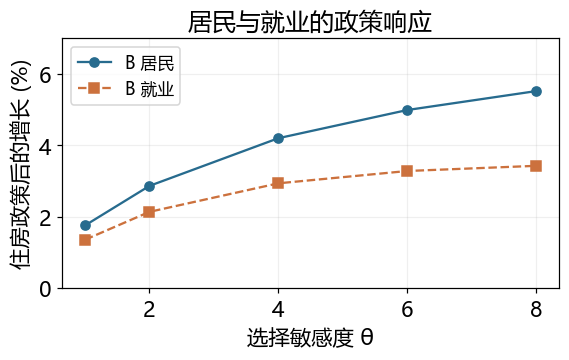

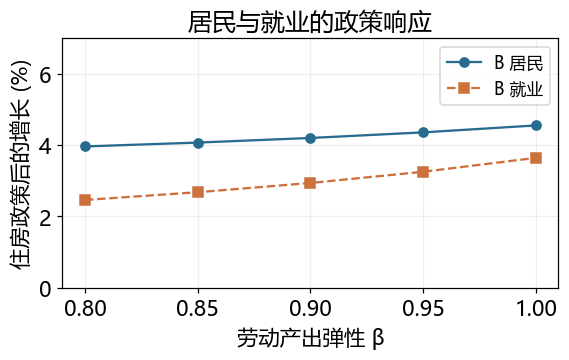

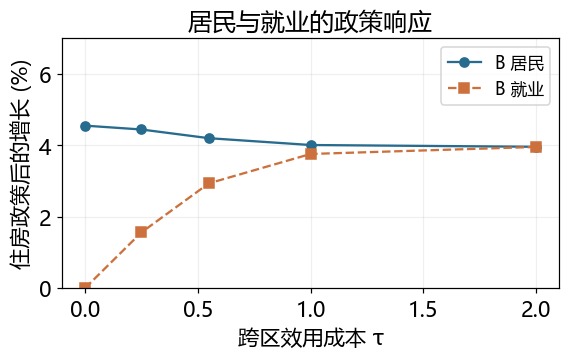

In [14]:
for axis,xlabel in [('theta','选择敏感度 θ'),('beta','劳动产出弹性 β'),('tau','跨区效用成本 τ')]:
    sub=sens[sens.axis==axis]
    fig,ax=plt.subplots(figsize=(5.4,3.5))
    ax.plot(sub[axis],sub.residents_B_change_pct,'o-',label='B 居民',color='#276b8e')
    ax.plot(sub[axis],sub.employment_B_change_pct,'s--',label='B 就业',color='#cc713d')
    ax.set_xlabel(xlabel);ax.set_ylabel('住房政策后的增长 (%)')
    ax.legend(fontsize=11);ax.grid(alpha=.2);ax.set_ylim(0,7)
    ax.set_title('居民与就业的政策响应',fontsize=16)
    fig.tight_layout();plt.show()


当通勤成本为 0、四种组合均可选时，联合选择概率可分解为居住地项与工作地项：

$$
p_{ij}=\frac{(B_{i}/r_{i}^{\alpha})^{\theta}}{\sum_{k}(B_{k}/r_{k}^{\alpha})^{\theta}}
\frac{w_{j}^{\theta}}{\sum_{\ell}w_{\ell}^{\theta}}.
$$

在本模型的固定生产基本面与总工人数下，住房扩建改变居住分布，工作地边际份额由工资与生产端条件共同决定，不依赖住房分布。因此，无通勤成本情景中的 B 居民增加，而就业数保持不变。这依赖本文的可分离偏好、同质工人和没有集聚外部性的设定，不能直接推广到所有城市模型。

当跨区通勤成本很高时，跨区份额趋近于 0，居民数与就业数逐渐重合，住房政策结果接近只允许本地工作的模型。这正好解释敏感性图中居民和就业两条曲线为何靠拢。比较这两个端点，比只观察一条曲线的斜率更容易理解通勤渠道。


In [15]:
extreme=sens[sens.axis.eq('tau') & sens.tau.isin([0.,2.])]
display(extreme[['tau','baseline_cross_commuters','residents_B_change_pct','employment_B_change_pct']].round(4))
print('tau=20 时的跨区人数：',float(hp['M'][0,1]+hp['M'][1,0]))


,tau,baseline_cross_commuters,residents_B_change_pct,employment_B_change_pct
10,0.0,60000.000,4.5549,-0.0000
14,2.0,40.242,3.9624,3.9576


tau=20 时的跨区人数： 2.1696314559342316e-30


成本为零时，住房政策引起居住重新配置，就业基本不变。成本很高时，交叉通勤接近零，R 与 E 的变化靠拢。tau=20 用于核验极限，并不代表现实城市的合理通勤成本。


## 7. 均衡核验 {#检查方程再解释结果}

每项检查分别记录数值误差、阈值和通过状态。选择概率的加总、行列边际、劳动边际产出、住房支出与普通商品资源核算共同约束结果；不能只相信优化器返回 success。

下面还检查零冲击、共同住房和生产率冲击、标签镜像、受限模型严格零流量、高成本极限，以及多个初值。


In [16]:
#| code-fold: true
def checks_for(s, p):
    """用最终联合流量重新检查市场、边际和普通商品核算。"""
    M, R, E, w, r = (s[k] for k in ['M','R','E','w','r'])
    v = np.log(p['B'])[:,None]+np.log(w)[None,:]-p['alpha']*np.log(r)[:,None]-p['tau']
    prob = softmax(np.where(p['mask'],p['theta']*v,-np.inf).ravel()).reshape(2,2)
    wage_income = np.sum(M*w[None,:])
    worker_c = (1-p['alpha'])*wage_income
    landlord_c = np.sum(r*s['H'])
    factor_c = np.sum((1-p['beta'])*s['Y'])
    return dict(total_population=abs(M.sum()/p['N']-1),
        row_residents=rel(M.sum(1),R), column_employment=rel(M.sum(0),E),
        joint_choices=float(np.max(np.abs(M/p['N']-prob))),
        housing_market=rel(r*s['H'],p['alpha']*(M@w)),
        marginal_product=rel(w,p['beta']*s['Z']*E**(p['beta']-1)),
        goods_resource=abs((worker_c+landlord_c+factor_c)/s['Y'].sum()-1),
        wage_bill=rel(M.sum(0)*w,p['beta']*s['Y']),
        root_residual=float(np.max(np.abs(s['residual']))),
        initial_spread=s['initial_spread'])


In [17]:
#| code-fold: true
import copy
checks={}
def check(name,error,tol=1e-8):
    checks[name]=dict(error=float(error),threshold=tol,passed=bool(np.isfinite(error) and error<=tol))
for name,s in states.items():
    for metric,error in checks_for(s,params[name]).items():
        check(name+'/'+metric,error)
for key,target in [('M',M0),('R',M0.sum(1)),('E',M0.sum(0)),('w',W0),('r',RENT0)]:
    check('baseline_restore/'+key,rel(base[key],target))
    check('zero_shock/'+key,rel(states['zero_shock'][key],base[key]))
for name,ws,rs,welf in [('common_housing_plus20',1.,1/1.2,1.2**ALPHA),
                      ('common_productivity_plus10',1.1,1.1,1.1**(1-ALPHA))]:
    s=states[name]
    for key,target in [('M',base['M']),('w',base['w']*ws),('r',base['r']*rs)]:
        check(name+'/scaling_'+key,rel(s[key],target))
    check(name+'/welfare_scaling',abs(np.exp(s['logW']-base['logW'])/welf-1))
swapped=copy.deepcopy(p)
for k in ['H','Z','B']: swapped[k]=p[k][::-1].copy()
for k in ['tau','mask']: swapped[k]=p[k][::-1,::-1].copy()
mirror=solve(swapped,(1.2,1.))
for key in ['R','E','w','r','M']:
    target=policy[key][::-1,::-1] if key=='M' else policy[key][::-1]
    check('label_mirror/'+key,rel(mirror[key],target))
check('label_mirror/welfare',abs(mirror['logW']-policy['logW']))
for name in ['restricted_baseline','restricted_B_housing_plus20']:
    check(name+'/cross_exact_zero',abs(states[name]['M'][0,1])+abs(states[name]['M'][1,0]),0.)
for key,target in [('R',M0.sum(1)),('E',M0.sum(0)),('w',W0),('r',RENT0)]:
    check('restricted_restore/'+key,rel(rb[key],target))
for key in ['R','E','w','r']:
    check('high_tau_limit/'+key,rel(hp[key],rp[key]))
check('high_tau_limit/cross_share',(hp['M'][0,1]+hp['M'][1,0])/N,1e-12)
check('high_tau_limit/welfare_gain',abs((hp['logW']-hb['logW'])-(rp['logW']-rb['logW'])))
# 受限模型的一维解析式另作检查，独立于二维数值算法。
analytical = THETA*ALPHA*np.log(1.2)/(1+THETA*(ALPHA+(1-ALPHA)*(1-BETA)))
check('restricted_analytical',abs(rp['xy'][0]-analytical))
check('mle/score',mle['mean_score_max'],1e-7)
check('mle/design_rank',abs(mle['design_rank']-2),0.)
for _,row in estimates.iterrows():
    check('mle/recovery_'+row.parameter,abs(row.z_from_truth),4.)
check('data/one_choice_per_set',float(np.max(np.abs(data.groupby('choice_set_id').chosen.sum()-1))),0.)
for row in sensitivity:
    if row['calibration_target']=='full_OD_baseline':
        check('sensitivity_OD/'+row['axis']+str(row['theta'])+str(row['beta']),row['baseline_OD_relative_error'])


In [18]:
check_table=pd.DataFrame.from_dict(checks,orient='index')
assert check_table.passed.all(),check_table[~check_table.passed]
print(f'全部 {len(check_table)} 项检查通过。')
print('基准复原最大相对误差：',check_table.loc[check_table.index.str.startswith('baseline_restore/'),'error'].max())
display(check_table.loc[['baseline_restore/M','B_housing_plus20/housing_market',
                       'B_housing_plus20/goods_resource','common_housing_plus20/welfare_scaling',
                       'common_productivity_plus10/welfare_scaling','high_tau_limit/cross_share']])


全部 484 项检查通过。
基准复原最大相对误差： 4.092726157978177e-15


,error,threshold,passed
baseline_restore/M,4.092726e-15,1.000000e-08,True
B_housing_plus20/housing_market,2.370726e-15,1.000000e-08,True
B_housing_plus20/goods_resource,5.551115e-16,1.000000e-08,True
common_housing_plus20/welfare_scaling,8.881784e-16,1.000000e-08,True
common_productivity_plus10/welfare_scaling,2.220446e-16,1.000000e-08,True
high_tau_limit/cross_share,1.808026e-35,1.000000e-12,True


::: {.callout-warning title="数值核验的边界" icon=false}

这些检查证明程序实现了给定方程，不能证明模型能够解释真实城市。模拟估计采用 IID 标准误；真实工资、租金和遗漏便利度的内生性仍需研究设计处理。AI 编程工具可以辅助实现，但不替代计量判断、软件验证和学术责任。

:::

### 再生模拟样本的可选核对 {.unlisted}

固定输入便于第一次复现。下面公开生成函数，并核对它是否恢复同一组选择；这一检查不将新样本替换到前面的估计。


In [19]:
#| code-fold: true
def simulate(n=SAMPLE_SIZE, seed=SEED):
    """每个任务独立抽工作地工资、居住地租金、双向通勤强度，再抽选择。"""
    rng = np.random.default_rng(seed)
    log_w = np.log(9600.) + rng.uniform(-.35, .35, (n, 2))
    log_r = np.log(120.) + rng.uniform(-.4, .4, (n, 2))
    cross_time = rng.uniform(.5, 1.5, (n, 2))
    home = np.array([0, 0, 1, 1])
    work = np.array([0, 1, 0, 1])
    cost = np.zeros((n, 4))
    cost[:, [1, 2]] = cross_time
    x = log_w[:, work] - ALPHA * log_r[:, home]
    prob = softmax(THETA*x - THETA*TAU*cost, axis=1)
    u = rng.random(n)
    choice = (u[:, None] > np.cumsum(prob, axis=1)).sum(1)
    return pd.DataFrame(dict(choice_set_id=np.repeat(np.arange(n), 4),
        home_region=np.tile(REGIONS[home], n), work_region=np.tile(REGIONS[work], n),
        commute_indicator=np.tile((home != work).astype(int), n),
        commute_multiplier=cost.ravel(), log_wage=log_w[:,work].ravel(),
        log_rent=log_r[:,home].ravel(),
        chosen=(np.arange(4)[None,:] == choice[:,None]).astype(int).ravel(),
        data_origin='synthetic_choice_experiment'))


In [20]:
regenerated=simulate()
assert np.array_equal(regenerated.chosen.to_numpy(),data.chosen.to_numpy())
for col in ['log_wage','log_rent','commute_multiplier']:
    np.testing.assert_allclose(regenerated[col],data[col],rtol=1e-12,atol=1e-12)
print('按公开种子与抽样顺序重新生成，选择完全一致、属性在浮点容差内一致。')


按公开种子与抽样顺序重新生成，选择完全一致、属性在浮点容差内一致。


## 8. 练习与排错 {#练习排错与下一步}

### 练习一：免费通勤

不看前面的图，先判断 tau=0 时，B 住房增加 20% 是否一定增加 B 就业。写出联合概率如何分解，再运行本节后的答案格。

### 练习二：较小住房冲击

保持主模型所有基本面，只把 B 住房增加 10%。检查 B 居民减就业是否等于净向 A 通勤。禁止在冲击后调用 calibrate 来重新匹配政策结果。

### 练习三：高通勤成本极限

提高跨区成本，与对角掩码模型比较。解释为什么零流量检查用绝对值或总人口归一化误差，不能除以零。

先写预测，再展开下面的可运行答案脚手架。


In [21]:
#| code-fold: true
# 答案脚手架：用同一套方程验证直觉，参数变化与住房政策分开实施。
free=calibrate(tau=0.)
free_base,free_policy=solve(free),solve(free,H_hat=(1.,1.2))
np.testing.assert_allclose(free_policy['E'],free_base['E'],rtol=1e-8)
small_policy=solve(p,H_hat=(1.,1.1))
np.testing.assert_allclose(small_policy['R'][1]-small_policy['E'][1],
                         small_policy['M'][1,0]-small_policy['M'][0,1],atol=1e-7)
for key in ['R','E','w','r']:
    np.testing.assert_allclose(hp[key],rp[key],rtol=1e-8)
print('三道练习核验通过。10% 住房冲击下 B 居民增量：',round(small_policy['R'][1]-base['R'][1],2))


三道练习核验通过。10% 住房冲击下 B 居民增量：

 1318.77


### 常见错误

| 现象 | 应检查什么 |
|---|---|
| 居民变化被解释为就业变化 | M 的行是居住地、列是工作地；用 E 计算工资 |
| 模拟通勤系数与参考值差很多 | 使用 commute_multiplier，而不是二元 commute_indicator |
| 住房看似出清但就业边际不一致 | 最终用联合流量重算市场条件，不只核对候选租金公式 |
| 报输入哈希不匹配 | Notebook 和 CSV 是否来自同一版本；不要跳过哈希检查 |
| 离线或 raw 下载失败 | 使用完整离线练习包，保留 data/ 相对路径 |
| 图中文字缺字 | 使用微软雅黑、黑体或 Noto Sans CJK SC；先看已算出的数值表 |
| 求根器报告无进展 | 看最终残差与市场条件；保留失败记录后求解同一方程，不改真值 |

本章通勤模型 的新增内容只有一个：居住地和工作地可以不同。它已经能说明住房供给冲击会沿着通勤流量传导，却没有加入企业集聚、居民便利度外部性、异质工人、交通建设成本或多个街区。

下一篇可以将政策从住房供给改为通勤成本，考察新地铁或道路改善如何改变居住、就业和房租。再往后，若让生产率随就业密度变化，就可以讨论交通改善和住房供给为何可能改变就业中心的位置，并与柏林墙研究中更完整的城市空间机制衔接。

读完本章后，继续阅读[柏林墙研究](evidence.qmd)，关注它如何用更丰富的数据识别通勤与集聚参数。两地区特例帮助理解记账与均衡反馈，不是该论文的复现。

配套材料：[参考脚本](../../articles/p05-commuting-qsm/code/qsm_commuting_demo.py)、[模型说明](../../articles/p05-commuting-qsm/model.md)、[实现练习提示词](../../articles/p05-commuting-qsm/prompts/01-implement.md)、[核验提示词](../../articles/p05-commuting-qsm/prompts/02-verify.md)。参考脚本用于对照，Notebook 本身不导入它。

## 9. Agent 实现与核验 {#借助-agent-实现校准与核验}

运行本章 Notebook 可以熟悉结果。若想练习把经济模型转成程序，可以另开一个 Agent 会话，只提供模型说明和固定输入，让它完成代码实现，再检查每一步是否对应经济方程。提示词需要说清变量口径、收入归属、政策中固定什么，以及如何验收。

### 9.1 独立练习目录 {#准备一个独立练习目录}

下载并解压[Agent 练习包](../../articles/p05-commuting-qsm/downloads/commuting-agent-inputs.zip)。其中只有模型说明、固定教学数据、提示词和许可文件，不含参考代码、Notebook 或政策结果。将新会话的工作目录设为解压目录。也可以从完整仓库复制同名文件，目录如下：

```text
commuting-agent-practice/
  model.md
  data/
    README.md
    teaching-baseline.csv
    synthetic-joint-choice-tasks.csv
  prompts/
    01-implement.md
    03-estimate-calibrate.md
    02-verify.md
```

固定 CSV 用于复现同一组教学任务，首次实现不重新抽样。先告诉 Agent 可用的 Python 环境；若它无法运行代码，应保留未验证状态，不能将生成了一段代码写成已完成数值计算。模型说明中的基准与真值是输入，政策后的均衡结果需要程序求出。

### 9.2 从零生成实现

把下面的提示词交给新会话。先检查它列出的方程与函数对应关系，再看实际输出。[下载提示词](../../articles/p05-commuting-qsm/prompts/01-implement.md)。

::: {.callout-note .agent-prompt title="Agent 提示词：生成实现" icon=false}

```text
请在当前练习目录独立用 Python 实现两地区通勤 QSM。
先阅读 model.md、data/README.md 和 data/ 下两份固定 CSV。
只使用这些输入，不读取参考程序、Notebook 或参考结果。
先检查运行环境并记录输入 SHA256，不安装或修改全局环境。

请按以下步骤编写并实际运行程序：
1. 说明 M 的行是居住地、列是工作地，R 为行和、E 为列和。
   列出选择、生产、工资、住房和福利方程及函数对应关系。
2. 用固定四选项样本估计 theta 与 kappa=theta*tau。
   使用连续变量 commute_multiplier，不以 commute_indicator 替代；
   保持 alpha 给定，计算信息矩阵 IID 标准误和含协方差的 Delta 法标准误。
   不重新生成样本，不把估计值自动代入主政策。
3. 主均衡使用 model.md 的教学真值。由基准流量和价格反演 H、Z，
   校准后先复原四格 OD、居民、就业、工资和租金。
4. 以 log(R_B/R_A)、log(E_B/E_A) 为未知量求均衡。
   由就业计算工资，再按条件工作地概率及居民收入计算候选租金。
   用联合概率重算流量，检验其边际和最终住房出清。
5. 只把 H_B 乘以 1.20，保持本组其他基本面与参数不变。
   另用对角选择掩码建立仅本地工作模型，独立校准其基准。
6. 完成 model.md 的敏感性网格、共同冲击、标签互换、高成本极限
   和至少五个初值检查。每次改变参数后按约定重新校准，
   每次政策计算中固定该组基本面；不能为得到预期结果临时调参。

代码写入 code/，结果写入新的 results/ 子目录，不覆盖已有成果。
至少导出估计与标准误、校准参数、均衡表、四格流量、敏感性表、
逐项误差及阈值、求解器诊断、实际运行命令与环境版本。
禁止硬编码政策答案。失败时保存错误和残差，不只报告 success。
所有数据与结果均为教学构造；福利是工人事前指数，不含建设成本。
首次实现完成并保存记录后，才能另行接收参考结果作对照。
```

:::

### 9.3 估计与校准 {#单独检查估计与校准}

读结果时，先看参数表能否区分教学真值、模拟估计值和反演基本面，再看基准误差表。若这一步混淆，求解器正常退出也不能说明政策计算可靠。这段提示词适合已有程序后的复查。[下载提示词](../../articles/p05-commuting-qsm/prompts/03-estimate-calibrate.md)。

::: {.callout-note .agent-prompt title="Agent 提示词：估计与校准" icon=false}

```text
请检查当前实现中的参数估计和基准校准，以 model.md 为准。
读取固定 CSV 并报告哈希；不要替换数据、真值或经济设定。

估计部分：
- 每个 choice_set_id 有 AA、AB、BA、BB 四项且恰好一项 chosen=1。
- 使用 V=theta*(log_wage-alpha*log_rent)-kappa*commute_multiplier；
  固定 alpha，检查 theta、kappa 的可识别秩、得分、优化状态和信息矩阵。
- 报告 theta、kappa、tau=kappa/theta、IID 标准误及 Delta 法标准误；
  Delta 法必须保留 theta 与 kappa 的协方差。
- 检查估计量与真值之差是否落在本教学样本的 4 个标准误内，
  但不得把这次恢复诊断称为覆盖率实验或真实城市识别。

校准部分：
- 单列教学真值、模拟估计值、反演基本面，不混用三种来源。
- 主均衡使用教学真值。按住房出清反演 H，按工资边际产出反演 Z；
  基准复原四格 OD、R、E、w、r 的相对误差应不超过 1e-8。
- theta 网格同步设 tau=ln(9)/theta 以匹配完整 OD；beta 网格重算 Z；
  单独改变 tau 时固定 theta，只匹配对称总量并允许 OD 改变。
  联合估计参数情景同样不能强行匹配原 OD。
- 在任一政策情景内固定已经校准的基本面，不再反演它们。

将估计诊断、校准复原误差和发现的问题分别导出。
如果需要修改代码，说明对应的方程或数据口径，修改后实际复测。
不通过调参、换样本或放宽阈值让检查通过。
```

:::

### 9.4 经济条件验收 {#用经济条件验收}

可以把程序与输出交给另一个会话，让它依据模型方程重新核算。不同会话也可能犯相同错误，因此最终仍须查看误差、阈值、零冲击、极端情形和初值比较。[下载核验提示词](../../articles/p05-commuting-qsm/prompts/02-verify.md)。

::: {.callout-note .agent-prompt title="Agent 提示词：核验结果" icon=false}

```text
请独立审查并重新运行当前练习目录的程序，以 model.md 为准。
不要修改模型、输入数据、真值或验收阈值。
请直接依据方程重算下列条件，不只调用原程序自己的验证函数：

1. 基准四格 OD、R、E、w、r 的相对误差不超过 1e-8。
2. 总工人数、M 的行列边际、联合选择概率、工资边际产出、
   住房出清及两地区合计的普通商品资源核算成立。
   住房支出使用 alpha*sum_j(w_j*M_ij)，工资使用工作地就业 E_j。
3. 零冲击返回基准；共同住房、共同生产率冲击满足 model.md 的性质；
   A/B 标签互换后结果镜像；至少五个初值的均衡解一致。
4. 对角掩码模型的跨区流量严格为 0，并符合受限解析式；
   tau=20 时跨区份额低于 1e-12，政策结果接近受限模型。
   免费通勤时检验联合概率的可分离性和住房政策下就业不变。
5. 检查全部敏感性情景及估计的秩、得分、信息矩阵、Delta 法协方差。
   一般相对误差或份额误差阈值为 1e-8；零流量不能用零作分母。
6. 图例必须与可见数据系列对应。严格为零的受限通勤注明为 0，
   不伪造可见柱形。福利不得写成扣除建设成本后的净社会收益。

保存每项误差、阈值、通过状态、实际命令和运行环境。
若求解器报告失败，保留诊断，检查残差与经济条件；
更换算法时求解同一方程，不更换模型。
有参考结果时，在首次独立实现结束后另做对照并报告差异。
区分自己重新计算的检查与引用的历史结果，不冒充新的独立试跑。
```

:::

验收时重点看四类文件：参数表中的估计值与标准误，基准表中的逐项误差，政策表中居民与就业的差别，以及核验文件中的失败项。参数恢复只是在已知生成机制下检查程序；真实工资、租金与通勤成本的内生性仍需研究设计处理。

此前版本的实现提示词已在独立新会话中实际试跑，并与参考实现进行数值对照。本节进一步细化了估计、校准和核验步骤；本轮核对了提示词与模型约定的一致性，没有再次进行新会话盲写测试。运行本章 Notebook、按提示词独立编程、用真实数据识别模型参数，是三项不同的工作。Agent 可以辅助代码和排错，经济设定、识别判断与结果解释仍需研究者负责。



## 10. 参考资料

1. Ahlfeldt, G. M., Redding, S. J., Sturm, D. M., & Wolf, N. (**2015**). The economics of density: Evidence from the Berlin Wall. *Econometrica*, 83(6), 2127–2189. [Link](https://doi.org/10.3982/ECTA10876), [PDF](https://swh.princeton.edu/~reddings/pubpapers/Berlin-Ecta-10876.pdf), [Google](<https://scholar.google.com/scholar?q=The+Economics+of+Density+Evidence+from+the+Berlin+Wall>).
2. Davis, M. A., & Ortalo-Magné, F. (**2011**). Household expenditures, wages, rents. *Review of Economic Dynamics*, 14(2), 248–261. [Link](https://doi.org/10.1016/j.red.2009.12.003), [PDF](https://doi.org/10.1016/j.red.2009.12.003), [Google](<https://scholar.google.com/scholar?q=Household+Expenditures+Wages+Rents>).
3. Redding, S. J. (**2023**). Quantitative urban models: From theory to data. *Journal of Economic Perspectives*, 37(2), 75–98. [Link](https://doi.org/10.1257/jep.37.2.75), [PDF](https://www.princeton.edu/~reddings/pubpapers/JEP-Urban-2023.pdf), [Google](<https://scholar.google.com/scholar?q=Quantitative+Urban+Models+From+Theory+to+Data>).

文献核查日期 (retrieved_date)：2026-10-05。Davis and Ortalo-Magné 的 PDF 字段使用 DOI 入口兜底，不表示已获取免费全文。
